In [ ]:
import tensorflow as tf
import keras
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
# Load a dataset (Rock-Paper-Scissors for more complexity)
dataset, dataset_info = tfds.load("rock_paper_scissors", as_supervised=True, with_info=True)
data_train, data_test = dataset["train"].batch(64), dataset["test"].batch(64)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/2520 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.8ED7Z0_3.0.0/rock_paper_scissors-train.tfre…

Generating test examples...:   0%|          | 0/372 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.8ED7Z0_3.0.0/rock_paper_scissors-test.tfrec…

Dataset rock_paper_scissors downloaded and prepared to /root/tensorflow_datasets/rock_paper_scissors/3.0.0. Subsequent calls will reuse this data.


In [ ]:
# Apply moderate data augmentation
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.2),
    keras.layers.RandomZoom(0.1)
])

In [ ]:
# Load EfficientNetB0 from Keras Applications
base_model = keras.applications.EfficientNetB0(
    weights="imagenet", include_top=False, input_shape=(224, 224, 3)
)
base_model.trainable = False  # Freeze the base model

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Build the model
inputs = keras.Input(shape=(300, 300, 3))  # Rock-Paper-Scissors images are 300x300
x = keras.layers.Resizing(224, 224)(inputs)  # Resize using Keras layer
x = data_augmentation(x)  # Apply augmentation
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation="relu")(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(3, activation="softmax")(x)  # 3 classes: Rock, Paper, Scissors
model = keras.Model(inputs, x)

In [ ]:
# Compile the model with a learning rate scheduler
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001, decay_steps=1500, decay_rate=0.85
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


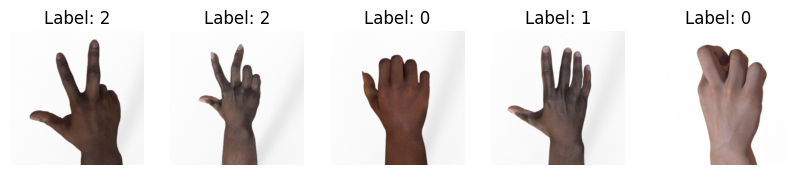

In [ ]:
# Visualize some images from dataset
sample_images, sample_labels = next(iter(data_train.take(1)))
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    axes[i].imshow(sample_images[i].numpy().astype("uint8"))
    axes[i].set_title(f"Label: {sample_labels[i].numpy()}")
    axes[i].axis("off")
plt.show()

In [ ]:
# Train the model
history = model.fit(data_train, validation_data=data_test, epochs=5)  # Moderate epochs

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 37s 315ms/step - accuracy: 0.8395 - loss: 0.4171 - val_accuracy: 0.6828 - val_loss: 0.8324
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 150ms/step - accuracy: 0.9901 - loss: 0.0445 - val_accuracy: 0.8522 - val_loss: 0.3650
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - accuracy: 0.9925 - loss: 0.0262 - val_accuracy: 0.7608 - val_loss: 0.5676
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.9974 - loss: 0.0155 - val_accuracy: 0.7043 - val_loss: 0.8300
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 150ms/step - accuracy: 0.9983 - loss: 0.0120 - val_accuracy: 0.7581 - val_loss: 0.6287


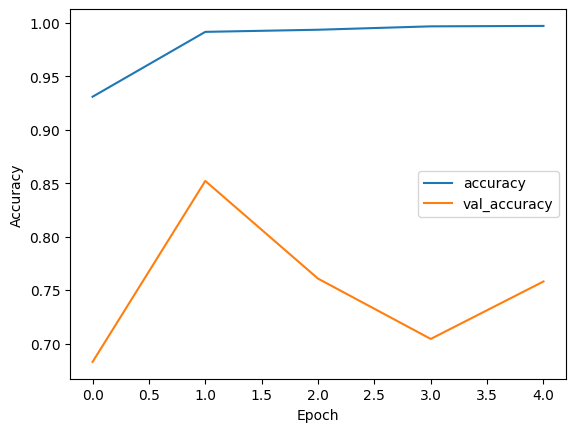

In [ ]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 647ms/step


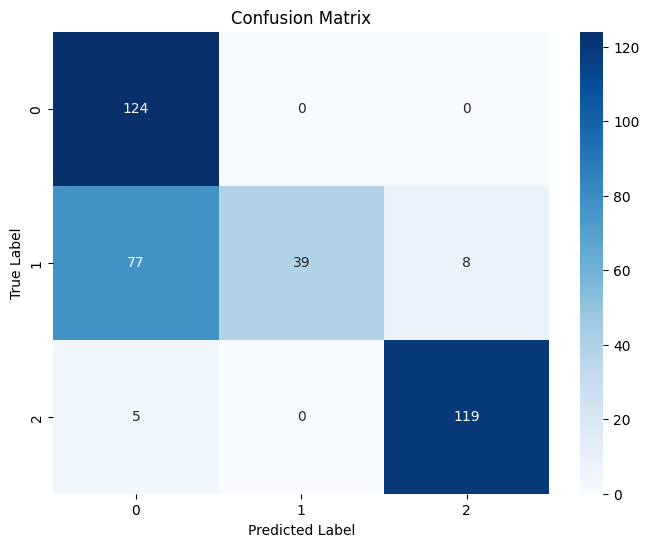

In [ ]:
# Generate predictions and confusion matrix
y_pred = np.argmax(model.predict(data_test), axis=1)
y_true = np.concatenate([y.numpy() for _, y in data_test], axis=0)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(3), yticklabels=range(3))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()